This notebook's goal is to conduct the STREAM analysis of clusters
- Inputs: raw QC filtered data + PROFILE results + cell_label and cell_label_color files
- Output: n × 4,768 cluster-by-gene binary matrix, with STREAM states as rows and genes as columns

Load packages and STREAM

In [148]:
#Load packages
%matplotlib inline
import stream as st
st.__version__
import numpy as np

Load the data

In [149]:
#load data
adata=st.read(file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/data_Nestorowa.tsv.gz')
#load labels
st.add_cell_labels(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/cell_label.tsv.gz')
st.add_cell_colors(adata,file_name='/Users/alicedecugis/Desktop/hematopoiesis/data/test_data/cell_label_color.tsv.gz')

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


Using default working directory.
Saving results in: /Users/alicedecugis/Desktop/hematopoiesis/stream_result


General data stats and vizualisation + remove/filter low expression genes

In [150]:
#visualize some of the data information
import numpy as np

min_cells = max(5, int(round(adata.shape[0] * 0.001)))

# Number of cells where each gene has expression > 1
n_cells_expressed = np.sum(adata.X > 1, axis=0)

# Genes to keep
keep = np.asarray(n_cells_expressed).ravel() >= min_cells

print("Total cells:", adata.n_obs)
print("Total genes:", adata.n_vars)
print("Genes before:", adata.n_vars)
print("Genes kept:", keep.sum())
print("Genes removed:", (~keep).sum())

Total cells: 1656
Total genes: 4768
Genes before: 4768
Genes kept: 4764
Genes removed: 4


Begin analysis

239 variable genes are selected


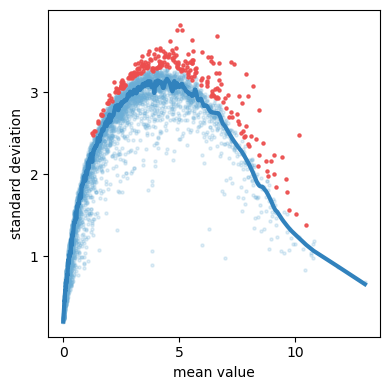

In [151]:
#visualize kept genes
st.select_variable_genes(adata)

feature var_genes is being used ...
4 cpus are being used ...


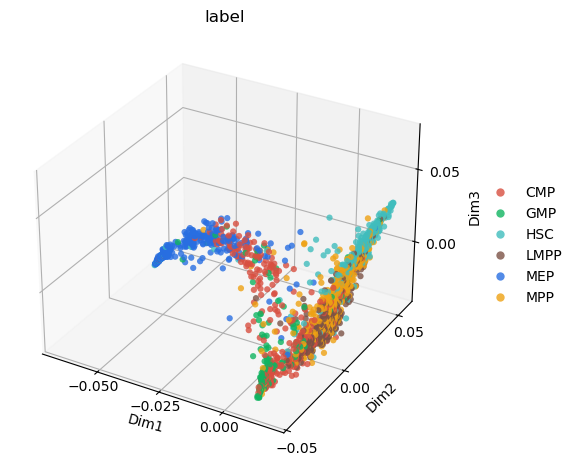

In [152]:
#do dimensionality reduction
st.dimension_reduction(
    adata,
    method="mlle",
    feature="var_genes",
    n_components=3,
    n_neighbors=50,
    n_jobs=4
)
st.plot_dimension_reduction(adata)


In [153]:
#workaround the expired STREAM version to do seed_elastic_principal_graph
import networkx as nx

nx.Graph.node = property(lambda G: G._node)
nx.DiGraph.node = property(lambda G: G._node)
nx.MultiGraph.node = property(lambda G: G._node)
nx.MultiDiGraph.node = property(lambda G: G._node)

print(nx.__version__)
print("G.node compatibility:", hasattr(nx.Graph(), "node"))

st.seed_elastic_principal_graph(
    adata,
    clustering="ap",
    damping=0.75,
    pref_perc=50
)

2.5
G.node compatibility: True
Seeding initial elastic principal graph...
Clustering...
Affinity propagation ...
The number of initial nodes is 21
Calculatng minimum spanning tree...
Number of initial branches: 7


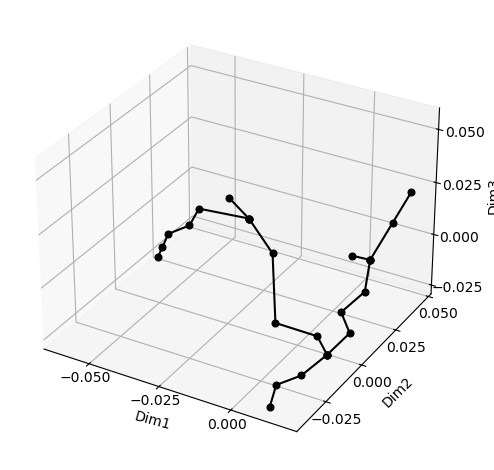

In [154]:
#plot the branches
st.plot_branches(adata)

epg_n_nodes is too small. It is corrected to the initial number of nodes plus incr_n_nodes
Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 51 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
3||51	7.311e-05	51	50	43	3	0	0	3.383e-05	3.131e-05	0.9813	0.9827	3.595e-05	3.326e-06	0.0001696	0.008651	0
4.793 sec elapsed
[[1]]
Ignoring unknown labels:
• linetype : ""

TYPE epg_obj: <class 'rpy2.rlike.container.NamedList'>
TYPE epg_obj[0]: <class 'rpy2.rlike.container.NamedList'>
epg_obj[0]: <rpy2.rlike.container.NamedList object at 0x29526a2c0>
NAMES epg_obj[0]: <bound method NamedList.names of <rpy2.rlike.container.NamedList object at 0x29526a2c0>>
Number of branches after learning elastic principal graph: 7


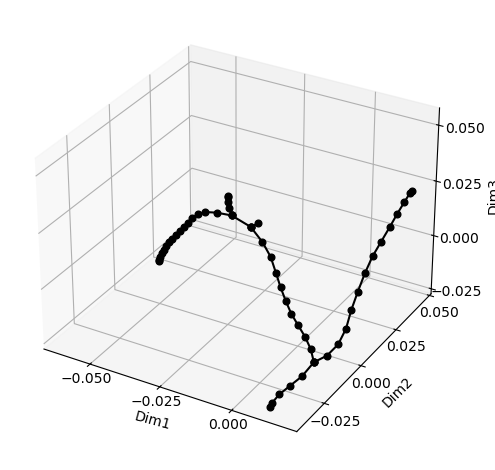

In [156]:
#plot the branches on the principal graph
st.elastic_principal_graph(adata)
st.plot_branches(adata)

Optimizing branching...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 81 nodes on 1656 points and 3 dimensions"
[1] "Using a single core"
Nodes = 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
3||81	5.567e-05	81	80	73	3	0	0	2.838e-05	2.698e-05	0.9843	0.9851	2.488e-05	2.416e-06	0.0001957	0.01585	0
2.06 sec elapsed
Number of branches after optimizing branching: 7


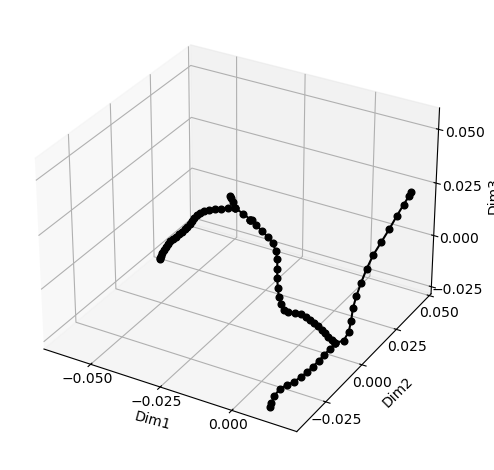

In [158]:
#optimize branching and plot
st.optimize_branching(adata,reset=True)
st.plot_branches(adata)

Extending leaves with additional nodes ...
Number of branches after extending leaves: 7


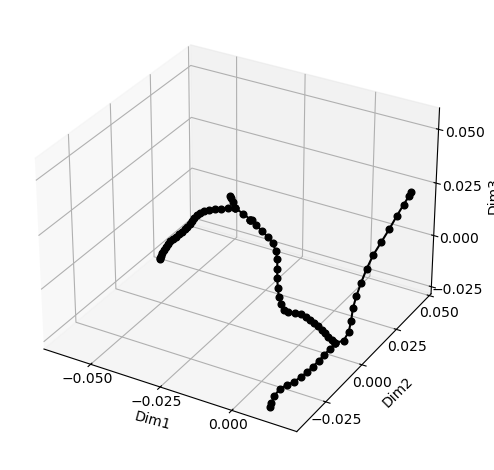

In [163]:
#extend the principal graph and plot
st.extend_elastic_principal_graph(adata)
st.plot_branches(adata)


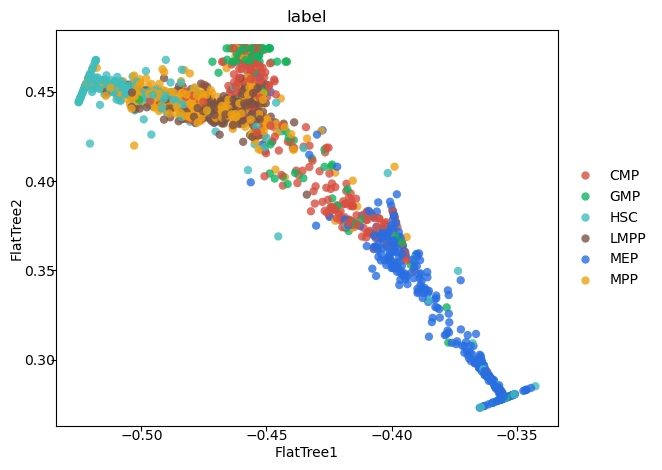

In [165]:
#plot tree 
st.plot_flat_tree(adata)

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


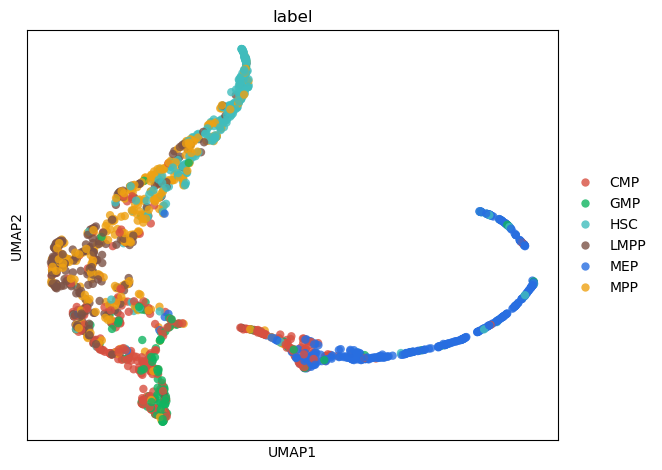

In [166]:
#UMAP visualization
st.plot_visualization_2D(adata,use_precomputed=False)

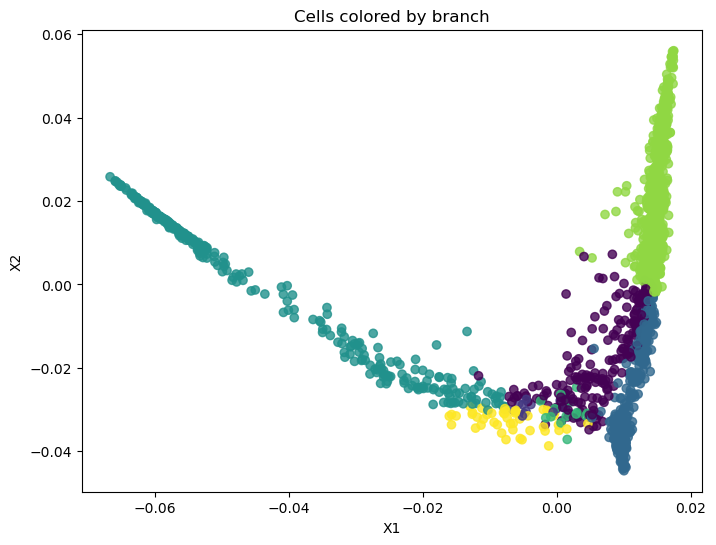

In [167]:
#workaround to plot with branch coloring 
import matplotlib.pyplot as plt
import pandas as pd

branch_codes = pd.Categorical(adata.obs["branch_id"]).codes

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    adata.obsm["X_dr"][:, 0],
    adata.obsm["X_dr"][:, 1],
    c=branch_codes,
    alpha=0.8
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Cells colored by branch")

plt.show()

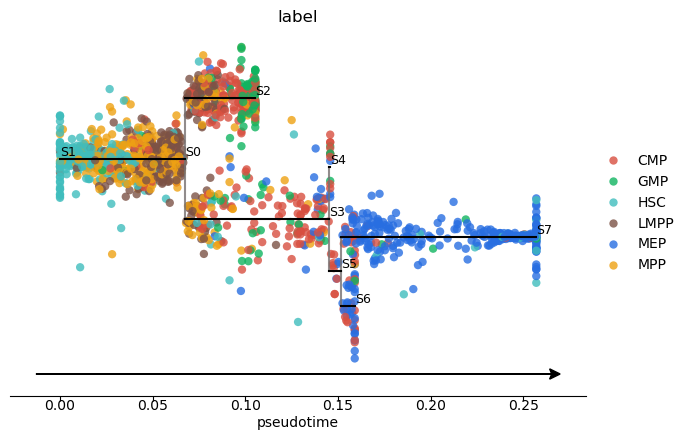

In [168]:
#problem: I have 7 nodes when the OG is 5 nodes
st.plot_stream_sc(
    adata,
    root="S1"
)

I have MORE nodes which is why the following stream plot has a weird rendering as the nodes are too close together

/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/extra.py:1008: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_edge_cellnum[edge_i][cell_i] = float(df_edge_i[df_edge_i['CELL_LABEL']==cell_i].shape[0])
/Use

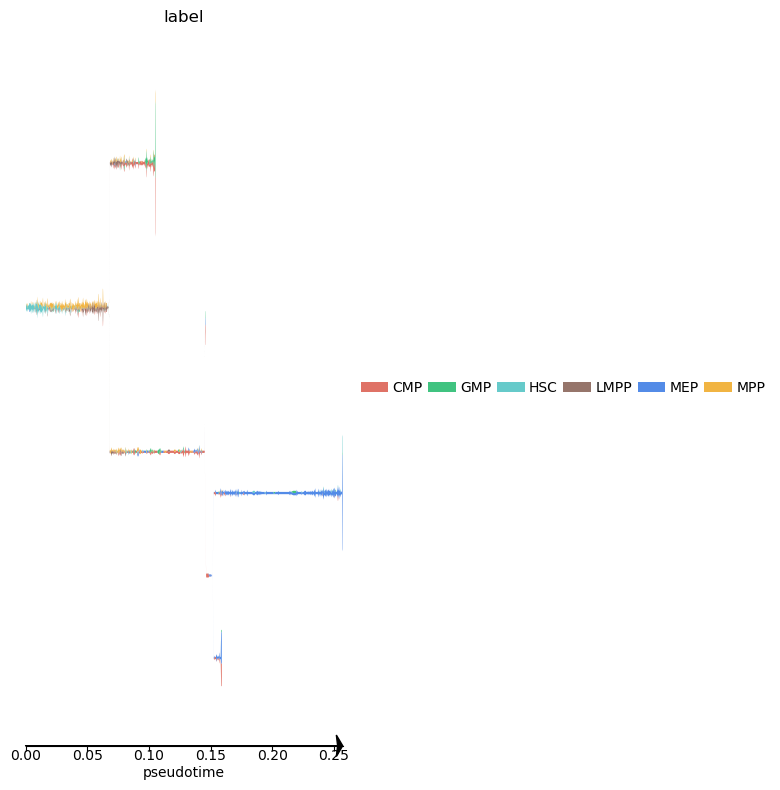

In [169]:
st.plot_stream(
    adata,
    root='S1',
    fig_size=(8, 8),
    fig_legend_ncol=6
)

In [170]:
#get a look at EPG edges
print("EPG edges:")
for a, b in adata.uns["epg"].edges():
    label_a = adata.uns["epg"].nodes[a].get("label", a)
    label_b = adata.uns["epg"].nodes[b].get("label", b)
    print(label_a, "--", label_b)

EPG edges:
0 -- 14
0 -- 18
1 -- 13
1 -- 14
2 -- 13
2 -- 22
3 -- 7
3 -- 47
4 -- 50
4 -- 78
4 -- 79
5 -- 10
5 -- 45
6 -- 8
6 -- 26
7 -- 17
8 -- 19
9 -- 15
9 -- 16
10 -- 68
10 -- 76
11 -- 12
11 -- 29
12 -- 34
15 -- 42
16 -- 21
17 -- 25
18 -- 23
19 -- 52
20 -- 26
20 -- 40
21 -- 27
22 -- 28
23 -- 38
24 -- 25
24 -- 51
27 -- 33
28 -- 30
29 -- 53
30 -- 35
31 -- 40
31 -- 43
32 -- 43
32 -- 57
33 -- 37
34 -- 36
35 -- 48
37 -- 44
38 -- 50
39 -- 42
39 -- 47
41 -- 46
41 -- 68
41 -- 80
45 -- 49
51 -- 55
52 -- 54
53 -- 59
54 -- 56
55 -- 58
56 -- 61
57 -- 60
58 -- 64
59 -- 62
60 -- 63
61 -- 70
62 -- 65
63 -- 66
64 -- 67
65 -- 71
66 -- 69
67 -- 72
69 -- 73
70 -- 80
71 -- 75
72 -- 74
73 -- 77
74 -- 76
75 -- 78
77 -- 79


Expected result from OG paper:OG
![STREAM trajectory](/Users/alicedecugis/Desktop/OG.png)

#### The order between horizontal branches from the same parent node has no meaning

#### Users can specify the order preference of nodes themselves

Checking out our transition markers

In [ ]:
st.detect_transition_markers(adata,root='S1',preference=['S4','S5'])

tm = adata.uns["transition_markers"]

adata.uns["transition_markers"] = {
    k: v for k, v in tm.items()
    if len(v) > 0
}

st.plot_transition_markers(adata)

Scanning all features ...
Filtering out markers that are expressed in less than 5 cells ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/st

1 cpus are being used ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3376: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_marker_detection[input_markers_expressed] = df_sc[input_markers_expressed].copy()
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/st

4767 markers are being scanned ...


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  df_stat_pval_qval.loc[markername,['stat','pval']] = spearmanr(df_cells_edge_i_sort.loc[:,markername],\
/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/stream/core.py:3420: ConstantInputWa

**Binarizing the clusters**
Goal:

1. PROFILE classifies each gene in each cell as 0, 1, or undetermined --> from PROFILE notebook
2. STREAM identifies clusters.
3. For each STREAM cluster, look at the PROFILE calls for all individual cells belonging to that cluster.
4. Apply the majority rule for each gene.
Result = cluster × gene binary matrix.

Output: should be in format of /Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_singlecell_binarized_observations.csv

FIRST run profile --> see Step1_Running_PROFILE.ipynb

In [ ]:
#Assign every cell to its STREAM state
node_to_state = {
    4: "S0",
    48: "S1",
    36: "S2",
    41: "S3",
    46: "S4",
    10: "S5",
    49: "S6",
    44: "S7"
}

adata.obs["node"]

cell_states = adata.obs["node"].map(node_to_state)
print(cell_states.value_counts())

node
S2    70
S7    53
S1    44
S6    25
S0    20
S4    15
S5     6
S3     2
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

#Load the PROFILE matrix generated in previous notebook
profile_matrix = pd.read_csv(
    "/Users/alicedecugis/Desktop/hematopoiesis/data/reproducing_results/nestorowa_binary_profiles.csv",
    index_col=0
)

print(profile_matrix.shape)
print(profile_matrix.iloc[:5, :5])

(1656, 4768)
   Clec1b  Kdm3a  Coro2b  8430408G22Rik  Clec9a
1     NaN    1.0     NaN            NaN     NaN
2     NaN    1.0     NaN            NaN     NaN
3     NaN    0.0     1.0            NaN     NaN
4     NaN    0.0     1.0            NaN     NaN
5     NaN    0.0     1.0            NaN     NaN


In [ ]:
# Make sure the cells match STREAM byrestore the cell IDs by position (we can do this since it is the same data origin, we are sure the order of the cells matches the cell ID)
profile_matrix.index = adata.obs_names
print(profile_matrix.index[:10].tolist())
print(adata.obs_names[:10].tolist())

print("Same cells:", profile_matrix.index.equals(adata.obs_names))

['HSPC_025', 'HSPC_031', 'HSPC_037', 'LT-HSC_001', 'HSPC_001', 'HSPC_008', 'HSPC_014', 'HSPC_020', 'HSPC_026', 'HSPC_038']
['HSPC_025', 'HSPC_031', 'HSPC_037', 'LT-HSC_001', 'HSPC_001', 'HSPC_008', 'HSPC_014', 'HSPC_020', 'HSPC_026', 'HSPC_038']
Same cells: True


In [ ]:
#Apply the PROFILE majority rule
states = ["S0", "S1", "S2", "S3", "S4", "S5", "S6", "S7"]

cluster_binary = pd.DataFrame(
    index=states,
    columns=profile_matrix.columns,
    dtype=float
)

for state in states:

    cells = cell_states[cell_states == state].index
    values = profile_matrix.loc[cells]

    for gene in values.columns:

        vals = values[gene].dropna()

        if len(vals) == 0:
            cluster_binary.loc[state, gene] = np.nan

        elif (vals == 1).sum() > (vals == 0).sum():
            cluster_binary.loc[state, gene] = 1

        elif (vals == 0).sum() > (vals == 1).sum():
            cluster_binary.loc[state, gene] = 0

        else:
            cluster_binary.loc[state, gene] = np.nan

In [ ]:
#check the output has correct dimensions
print(cluster_binary.shape)

(8, 4768)


In [ ]:
#save the output
output_file = "/Users/alicedecugis/Desktop/hematopoiesis/data/reproducing_results/nestorowa_STREAM_cluster_binary.csv"

cluster_binary.to_csv(
    output_file,
    index=True,
    na_rep="NA"
)

print(f"Saved to: {output_file}")

Saved to: /Users/alicedecugis/Desktop/hematopoiesis/data/reproducing_results/nestorowa_STREAM_cluster_binary.csv


Checking my results compared to those of the article "Among the 4768 hyper-variable genes selected by STREAM, 1519 have been classified with different binary values in at least two different clusters, and 1369 are classified as binary values in all clusters"

In [ ]:
#Count genes that differ between at least two clusters
variable_between_clusters = []

for gene in cluster_binary.columns:
    values = cluster_binary[gene].dropna().unique()

    if 0 in values and 1 in values:
        variable_between_clusters.append(gene)

print("Genes with different binary values in ≥2 clusters:",
      len(variable_between_clusters))

#print(variable_between_clusters)

Genes with different binary values in ≥2 clusters: 1805


In [ ]:
#Count genes classified as binary in all 8 clusters
binary_in_all_clusters = []

for gene in cluster_binary.columns:
    values = cluster_binary[gene]

    if values.notna().all() and set(values.unique()).issubset({0, 1}):
        binary_in_all_clusters.append(gene)

print("Genes binary in all clusters:",
      len(binary_in_all_clusters))

Genes binary in all clusters: 1320
